In [1]:
import os
import cv2
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [4]:
dataset_path = r"C:\Users\Abhi\Desktop\training_set\training_set"

In [5]:
data = []
labels = []

categories = ["cats", "dogs"]

for category in categories:

    folder_path = os.path.join(dataset_path, category)

    label = categories.index(category)

    images = os.listdir(folder_path)[:200]

    for img in images:

        try:
            img_path = os.path.join(folder_path, img)

            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            image = cv2.resize(image, (32, 32))

            data.append(image.flatten())

            labels.append(label)

        except:
            pass

print("Images Loaded:", len(data))

Images Loaded: 400


In [6]:
X = np.array(data)
y = np.array(labels)

print(X.shape)
print(y.shape)

(400, 1024)
(400,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = SVC(kernel="linear")

model.fit(X_train, y_train)

SVC(kernel='linear')

In [9]:
y_pred = model.predict(X_test)

In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 0.6125


In [13]:
images = os.listdir(folder_path)[:100]

In [14]:
print(os.listdir(r"C:\Users\Abhi\Desktop\training_set\training_set"))

['cats', 'dogs']


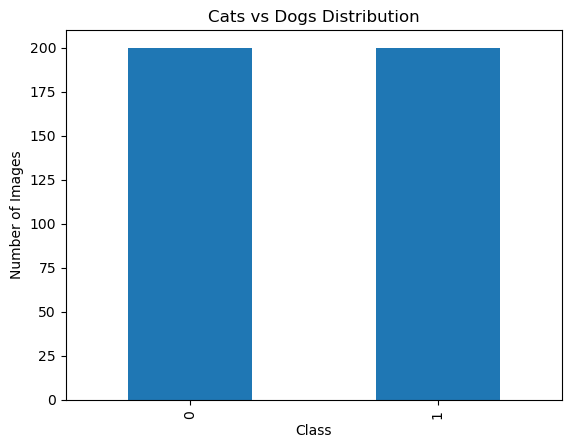

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

pd.Series(labels).value_counts().plot(kind='bar')

plt.title("Cats vs Dogs Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

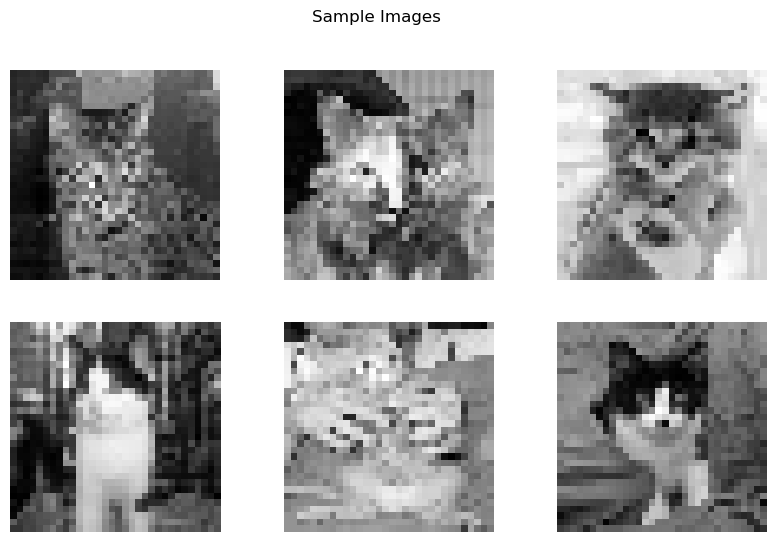

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(data[i].reshape(32,32), cmap='gray')
    plt.axis('off')

plt.suptitle("Sample Images")
plt.show()

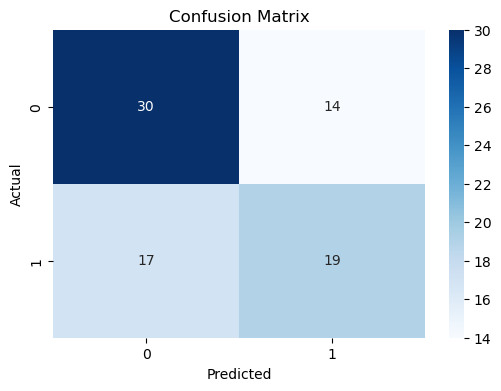

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

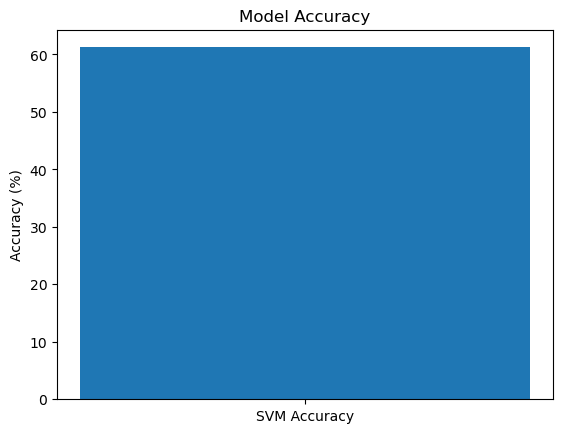

In [18]:
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)

plt.bar(['SVM Accuracy'], [accuracy*100])

plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy")

plt.show()

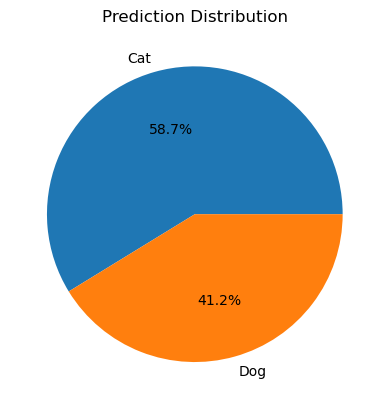

In [19]:
import numpy as np
import matplotlib.pyplot as plt

classes = ['Cat','Dog']

pred_counts = [sum(y_pred==0), sum(y_pred==1)]

plt.pie(pred_counts,
        labels=classes,
        autopct='%1.1f%%')

plt.title("Prediction Distribution")

plt.show()

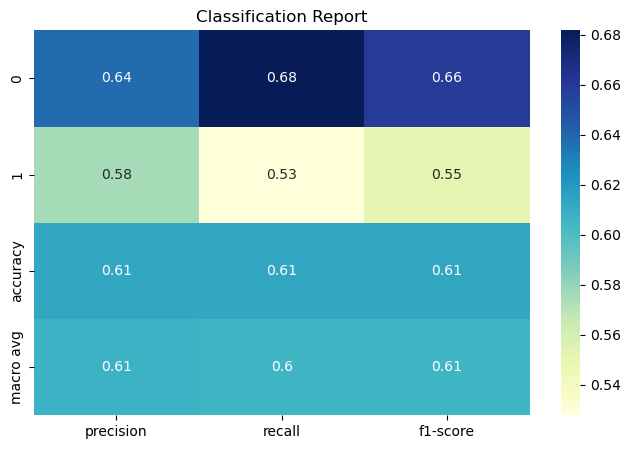

In [20]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,5))

sns.heatmap(
    df.iloc[:-1,:-1],
    annot=True,
    cmap="YlGnBu"
)

plt.title("Classification Report")
plt.show()